In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import os

In [3]:
DATA_PATH = "CNN_project_cars"

print(os.listdir(DATA_PATH))

['anno_test.csv', 'anno_train.csv', 'car_data', 'names.csv']


In [4]:
print(os.listdir(f"{DATA_PATH}/car_data"))

['car_data']


In [5]:
CAR_PATH = f"{DATA_PATH}/car_data/car_data"

print(os.listdir(CAR_PATH))

['test', 'train']


In [6]:
TRAIN_PATH = f"{CAR_PATH}/train"
TEST_PATH = f"{CAR_PATH}/test"

print(os.listdir(TRAIN_PATH)[:20])

['Acura Integra Type R 2001', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008', 'Acura TSX Sedan 2012', 'Acura ZDX Hatchback 2012', 'AM General Hummer SUV 2000', 'Aston Martin V8 Vantage Convertible 2012', 'Aston Martin V8 Vantage Coupe 2012', 'Aston Martin Virage Convertible 2012', 'Aston Martin Virage Coupe 2012', 'Audi 100 Sedan 1994', 'Audi 100 Wagon 1994', 'Audi A5 Coupe 2012', 'Audi R8 Coupe 2012', 'Audi RS 4 Convertible 2008', 'Audi S4 Sedan 2007', 'Audi S4 Sedan 2012', 'Audi S5 Convertible 2012', 'Audi S5 Coupe 2012']


In [7]:
labels = {}

for i, car_name in enumerate(os.listdir(TRAIN_PATH)):
    labels[car_name] = i

labels

{'Acura Integra Type R 2001': 0,
 'Acura RL Sedan 2012': 1,
 'Acura TL Sedan 2012': 2,
 'Acura TL Type-S 2008': 3,
 'Acura TSX Sedan 2012': 4,
 'Acura ZDX Hatchback 2012': 5,
 'AM General Hummer SUV 2000': 6,
 'Aston Martin V8 Vantage Convertible 2012': 7,
 'Aston Martin V8 Vantage Coupe 2012': 8,
 'Aston Martin Virage Convertible 2012': 9,
 'Aston Martin Virage Coupe 2012': 10,
 'Audi 100 Sedan 1994': 11,
 'Audi 100 Wagon 1994': 12,
 'Audi A5 Coupe 2012': 13,
 'Audi R8 Coupe 2012': 14,
 'Audi RS 4 Convertible 2008': 15,
 'Audi S4 Sedan 2007': 16,
 'Audi S4 Sedan 2012': 17,
 'Audi S5 Convertible 2012': 18,
 'Audi S5 Coupe 2012': 19,
 'Audi S6 Sedan 2011': 20,
 'Audi TT Hatchback 2011': 21,
 'Audi TT RS Coupe 2012': 22,
 'Audi TTS Coupe 2012': 23,
 'Audi V8 Sedan 1994': 24,
 'Bentley Arnage Sedan 2009': 25,
 'Bentley Continental Flying Spur Sedan 2007': 26,
 'Bentley Continental GT Coupe 2007': 27,
 'Bentley Continental GT Coupe 2012': 28,
 'Bentley Continental Supersports Conv. Convert

In [8]:
classes = sorted(os.listdir(TRAIN_PATH))

labels = {}

for i, car_name in enumerate(classes):
    labels[car_name] = i

print(labels)
print("Количество классов:", len(labels))

{'AM General Hummer SUV 2000': 0, 'Acura Integra Type R 2001': 1, 'Acura RL Sedan 2012': 2, 'Acura TL Sedan 2012': 3, 'Acura TL Type-S 2008': 4, 'Acura TSX Sedan 2012': 5, 'Acura ZDX Hatchback 2012': 6, 'Aston Martin V8 Vantage Convertible 2012': 7, 'Aston Martin V8 Vantage Coupe 2012': 8, 'Aston Martin Virage Convertible 2012': 9, 'Aston Martin Virage Coupe 2012': 10, 'Audi 100 Sedan 1994': 11, 'Audi 100 Wagon 1994': 12, 'Audi A5 Coupe 2012': 13, 'Audi R8 Coupe 2012': 14, 'Audi RS 4 Convertible 2008': 15, 'Audi S4 Sedan 2007': 16, 'Audi S4 Sedan 2012': 17, 'Audi S5 Convertible 2012': 18, 'Audi S5 Coupe 2012': 19, 'Audi S6 Sedan 2011': 20, 'Audi TT Hatchback 2011': 21, 'Audi TT RS Coupe 2012': 22, 'Audi TTS Coupe 2012': 23, 'Audi V8 Sedan 1994': 24, 'BMW 1 Series Convertible 2012': 25, 'BMW 1 Series Coupe 2012': 26, 'BMW 3 Series Sedan 2012': 27, 'BMW 3 Series Wagon 2012': 28, 'BMW 6 Series Convertible 2007': 29, 'BMW ActiveHybrid 5 Sedan 2012': 30, 'BMW M3 Coupe 2012': 31, 'BMW M5 Sed

In [9]:
class_names = {}

for car_name, number in labels.items():
    class_names[number] = car_name

print(class_names)

{0: 'AM General Hummer SUV 2000', 1: 'Acura Integra Type R 2001', 2: 'Acura RL Sedan 2012', 3: 'Acura TL Sedan 2012', 4: 'Acura TL Type-S 2008', 5: 'Acura TSX Sedan 2012', 6: 'Acura ZDX Hatchback 2012', 7: 'Aston Martin V8 Vantage Convertible 2012', 8: 'Aston Martin V8 Vantage Coupe 2012', 9: 'Aston Martin Virage Convertible 2012', 10: 'Aston Martin Virage Coupe 2012', 11: 'Audi 100 Sedan 1994', 12: 'Audi 100 Wagon 1994', 13: 'Audi A5 Coupe 2012', 14: 'Audi R8 Coupe 2012', 15: 'Audi RS 4 Convertible 2008', 16: 'Audi S4 Sedan 2007', 17: 'Audi S4 Sedan 2012', 18: 'Audi S5 Convertible 2012', 19: 'Audi S5 Coupe 2012', 20: 'Audi S6 Sedan 2011', 21: 'Audi TT Hatchback 2011', 22: 'Audi TT RS Coupe 2012', 23: 'Audi TTS Coupe 2012', 24: 'Audi V8 Sedan 1994', 25: 'BMW 1 Series Convertible 2012', 26: 'BMW 1 Series Coupe 2012', 27: 'BMW 3 Series Sedan 2012', 28: 'BMW 3 Series Wagon 2012', 29: 'BMW 6 Series Convertible 2007', 30: 'BMW ActiveHybrid 5 Sedan 2012', 31: 'BMW M3 Coupe 2012', 32: 'BMW M5

In [10]:
print("Количество классов:", len(classes))

total_images = 0

for car_name in classes:
    total_images += len(os.listdir(f"{TRAIN_PATH}/{car_name}"))

print("Количество train изображений:", total_images)

Количество классов: 196
Количество train изображений: 8144


In [12]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 8144 files belonging to 196 classes.
Using 6516 files for training.
Found 8144 files belonging to 196 classes.
Using 1628 files for validation.


In [13]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Первые 10 labels:", labels[:10].numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Первые 10 labels: [ 78  82  55 136  45 194 192  11 110  37]


In [14]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [15]:
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [16]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    196,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

In [17]:
predicted_id = np.argmax(prediction)

NameError: name 'prediction' is not defined

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 196)                 │         251,076 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,300,647 (16.41 MB)

 Trainable params: 251,076 (980.77 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


204/204 ━━━━━━━━━━━━━━━━━━━━ 158s 743ms/step - accuracy: 0.0723 - loss: 4.6621 - val_accuracy: 0.2224 - val_loss: 3.8983
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 129s 633ms/step - accuracy: 0.2617 - loss: 3.5498 - val_accuracy: 0.2979 - val_loss: 3.3394
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 183s 897ms/step - accuracy: 0.3912 - loss: 2.9688 - val_accuracy: 0.3514 - val_loss: 3.0175
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 167s 817ms/step - accuracy: 0.4702 - loss: 2.5732 - val_accuracy: 0.3643 - val_loss: 2.8122
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 170s 832ms/step - accuracy: 0.5264 - loss: 2.2862 - val_accuracy: 0.3882 - val_loss: 2.6569
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 180s 882ms/step - accuracy: 0.5732 - loss: 2.0711 - val_accuracy: 0.4103 - val_loss: 2.5456
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 160s 785ms/step - accuracy: 0.6125 - loss: 1.8878 - val_accuracy: 0.4115 - val_loss: 2.4557
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 208s 811ms/step - accuracy: 0.6367 - loss: 1.74

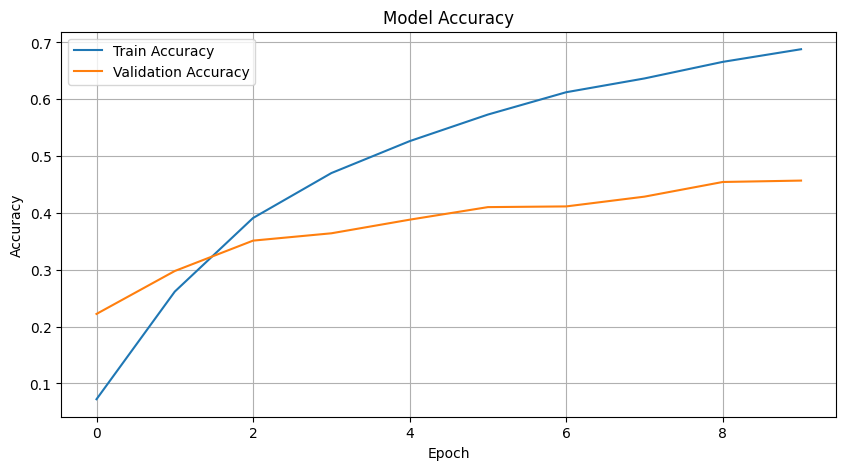

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

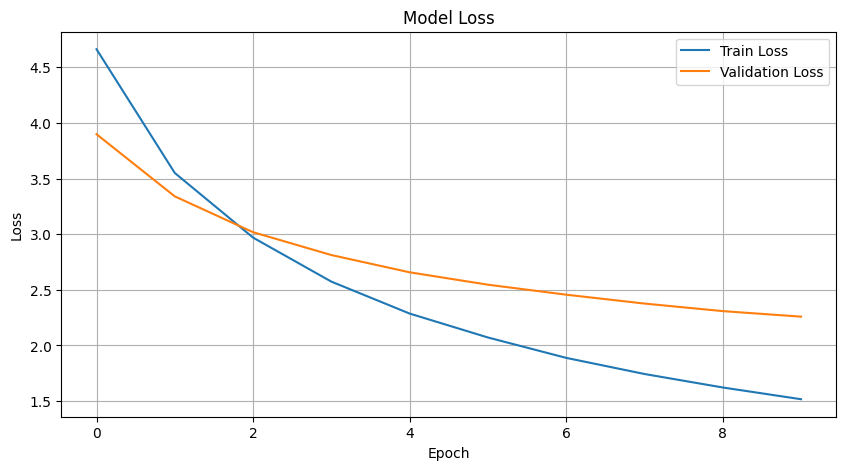

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

In [22]:
model.save("car_model.keras")

In [23]:
import pickle

with open("class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

In [24]:
print(os.path.exists("car_model.keras"))
print(os.path.exists("class_names.pkl"))

True
True
